In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def calc_fee(pos_pct, capital=1_000_000):
    return round((pos_pct / 100) ** 2 * capital)

In [3]:
def calc_pnl(pos_pct, pos_change_pct, capital=1_000_000):
    fee = calc_fee(pos_pct)
    return pos_pct / 100 * capital * pos_change_pct / 100 - fee

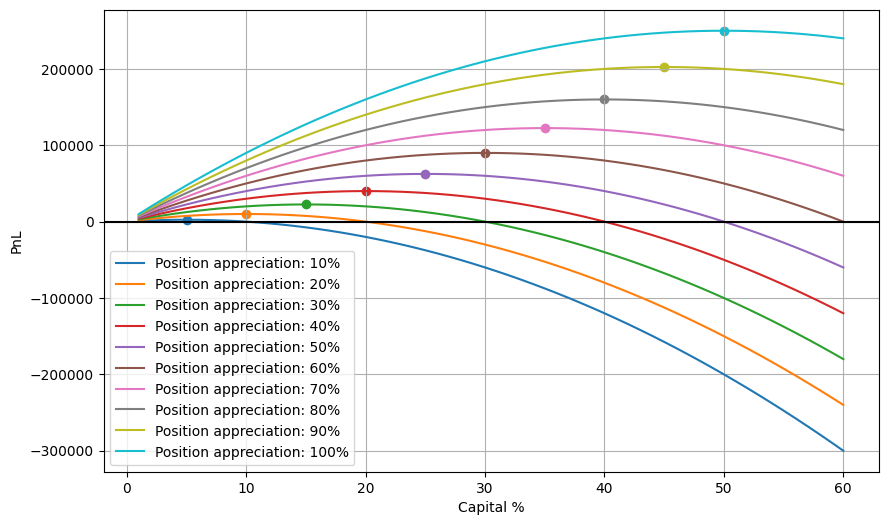

In [4]:
plt.figure(figsize=(10, 6))
for pct in np.arange(10, 101, 10):
    pnls = [calc_pnl(pos_pct=x, pos_change_pct=pct) for x in np.arange(1, 61)]
    plt.plot(np.arange(1, 61), pnls, label=f'Position appreciation: {pct}%')
    plt.scatter(np.argmax(pnls) + 1, pnls[np.argmax(pnls)])
plt.axhline(0, c='k')
plt.grid('on')
plt.xlabel('Capital %')
plt.ylabel('PnL')
plt.legend()
plt.show()

In [5]:
def opt_pos_pct(pos_change_pct):
    pnls = []
    for i in range(1, 101):
        pnls.append(calc_pnl(pos_pct=i, pos_change_pct=pos_change_pct))
    return np.argmax(pnls) + 1

In [6]:
for i in range(10, 121, 10):
    print(f'Position appreciation: {i}% --> Optimal capital percentage: {opt_pos_pct(i)}%')

Position appreciation: 10% --> Optimal capital percentage: 5%
Position appreciation: 20% --> Optimal capital percentage: 10%
Position appreciation: 30% --> Optimal capital percentage: 15%
Position appreciation: 40% --> Optimal capital percentage: 20%
Position appreciation: 50% --> Optimal capital percentage: 25%
Position appreciation: 60% --> Optimal capital percentage: 30%
Position appreciation: 70% --> Optimal capital percentage: 35%
Position appreciation: 80% --> Optimal capital percentage: 40%
Position appreciation: 90% --> Optimal capital percentage: 45%
Position appreciation: 100% --> Optimal capital percentage: 50%
Position appreciation: 110% --> Optimal capital percentage: 55%
Position appreciation: 120% --> Optimal capital percentage: 60%


# Portfolio

True return for each product from Prosperity 2:
- Refrigerators: 2
- Earrings: 12
- Blankets: -33
- Sleds: -28
- Sculptures: 20
- PS6: 31
- Serum: -82
- Lamps: 0
- Chocolate: 0

True return for each product from Prosperity 3:
- Cacti Needle: -41.20,
- Quantum Coffee: -66.79,
- Ranch sauce: -0.72,
- Solar panels: -8.90,
- Moonshine: 3.00,
- Haystacks: -0.48,
- Red Flags: 50.90,
- Striped shirts: 0.21,
- VR Monocle: 22.40

Estimated returns for this round:
- Obsidian cutlery: 30-50
- Pyroflex cells: (-10)-(-25)
- Thermalite core: 20-30
- Lava cake: (-60)-(-80)
- Magma ink: 0
- Scoria paste: 0
- Ashes of the Phoenix: (-10)-(-30)
- Volcanic incense: 0-(-5)
- Sulfur reactor: 10-20

In [7]:
price_changes = {
    'Obsidian cutlery': 40,
    'Pyroflex cells': -20,
    'Thermalite core': 27,
    'Lava cake': -70,
    'Magma ink': 0,
    'Scoria paste': 0,
    'Ashes of the Phoenix': -10,
    'Volcanic incense': -5,
    'Sulfur reactor': 15,
}

In [8]:
positions = {}
for k, v in price_changes.items():
    positions[k] = np.sign(v) * opt_pos_pct(np.abs(v))

In [9]:
print("Positions: \n")
for k, v in positions.items():
    print(f"{k}: {v}%")

Positions: 

Obsidian cutlery: 20%
Pyroflex cells: -10%
Thermalite core: 13%
Lava cake: -35%
Magma ink: 0%
Scoria paste: 0%
Ashes of the Phoenix: -5%
Volcanic incense: -2%
Sulfur reactor: 7%


In [10]:
print(f"Capital used: {np.sum(np.abs(list(positions.values())))}%")

Capital used: 92%


In [11]:
pnls = {}
for k, v in positions.items():
    pnls[k] = calc_pnl(abs(v), abs(price_changes[k]), capital=1_000_000)

In [12]:
print("PnLs: \n")
for k, v in pnls.items():
    print(f"{k}: {v}")

PnLs: 

Obsidian cutlery: 40000.0
Pyroflex cells: 10000.0
Thermalite core: 18200.0
Lava cake: 122500.0
Magma ink: 0.0
Scoria paste: 0.0
Ashes of the Phoenix: 2500.0
Volcanic incense: 600.0
Sulfur reactor: 5600.0


In [13]:
print(f"Expected PnL: {round(np.sum(list(pnls.values())))}")

Expected PnL: 199400


# Results

In [14]:
true_net_pnls = {
    'Obsidian cutlery': -20169,
    'Pyroflex cells': 9534,
    'Thermalite core': 11908,
    'Lava cake': 99237,
    'Magma ink': 0,
    'Scoria paste': 0,
    'Ashes of the Phoenix': -748,
    'Volcanic incense': 2514,
    'Sulfur reactor': 7297,
}

In [15]:
print(f"Final PnL: {round(np.sum(list(true_net_pnls.values())))}")

Final PnL: 109573


In [16]:
true_gross_pnls = {k: v + calc_fee(positions[k]) for k, v in true_net_pnls.items()}

In [17]:
true_price_changes = {
    k: (v / (positions[k] / 100 * 1_000_000) * 100 if v != 0 else "Unknown") 
    for k, v in true_gross_pnls.items()
}

In [18]:
true_price_changes['Magma ink'] = 2.23

In [19]:
print("True price changes: \n")
for k, v in true_price_changes.items():
    print(f"{k}: {v}%")

True price changes: 

Obsidian cutlery: 9.9155%
Pyroflex cells: -19.534000000000002%
Thermalite core: 22.16%
Lava cake: -63.35342857142857%
Magma ink: 2.23%
Scoria paste: Unknown%
Ashes of the Phoenix: -3.504%
Volcanic incense: -14.57%
Sulfur reactor: 17.424285714285716%


In [20]:
print("Predicted price changes: \n")
for k, v in price_changes.items():
    print(f"{k}: {v}%")

Predicted price changes: 

Obsidian cutlery: 40%
Pyroflex cells: -20%
Thermalite core: 27%
Lava cake: -70%
Magma ink: 0%
Scoria paste: 0%
Ashes of the Phoenix: -10%
Volcanic incense: -5%
Sulfur reactor: 15%
